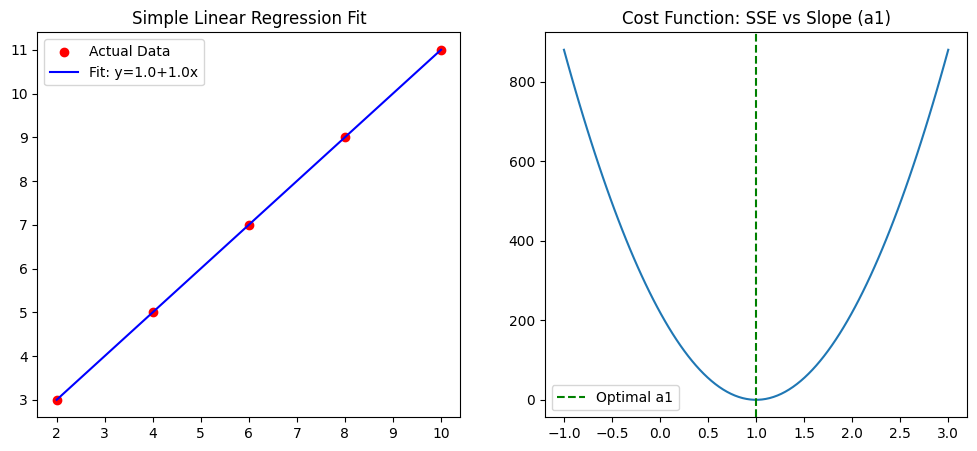

Scratch Results: a0=1.0, a1=1.0
Metrics: R2=1.00, MAE=0.00, SSE=0.00


In [1]:
### simple linear regression scrap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dataset from assignment [cite: 25, 26]
X = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
y = np.array([3, 5, 7, 9, 11])

# --- METHOD 1: Least Squares / Normal Equations (Scratch) ---
def simple_lr_scratch(x, y):
    n = len(x)
    x = x.flatten()
    # Formulas for b (slope) and a (intercept) [cite: 30]
    b = (n * np.sum(x*y) - np.sum(x)*np.sum(y)) / (n * np.sum(x**2) - np.sum(x)**2)
    a = np.mean(y) - b * np.mean(x)
    return a, b

a0, a1 = simple_lr_scratch(X, y)

# --- METHOD 2: Gradient Descent (Scratch) ---
def gradient_descent(x, y, alpha=0.01, epochs=1000):
    n = len(x)
    x = x.flatten()
    w0, w1 = 0.0, 0.0 # Initialize weights [cite: 43]
    for _ in range(epochs):
        y_pred = w0 + w1 * x
        # Gradient update rules [cite: 43]
        dw0 = (-2/n) * np.sum(y - y_pred)
        dw1 = (-2/n) * np.sum(x * (y - y_pred))
        w0 -= alpha * dw0
        w1 -= alpha * dw1
    return w0, w1

# --- EVALUATION METRICS (Scratch) ---
y_pred = a0 + a1 * X.flatten()
sse = np.sum((y - y_pred)**2) # [cite: 33]
ssr = np.sum((y_pred - np.mean(y))**2)
sst = np.sum((y - np.mean(y))**2)
r2 = 1 - (sse / sst) # [cite: 37]
mae = np.mean(np.abs(y - y_pred)) # [cite: 37]
mape = np.mean(np.abs((y - y_pred) / y)) * 100

# --- PLOTTING ---
plt.figure(figsize=(12, 5))
# Plot 1: Regression Fit
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='red', label='Actual Data')
plt.plot(X, y_pred, color='blue', label=f'Fit: y={a0:.1f}+{a1:.1f}x')
plt.title("Simple Linear Regression Fit")
plt.legend()

# Plot 2: SSE Curve (Varying a1) [cite: 34]
b_range = np.linspace(a1-2, a1+2, 100)
sse_vals = [np.sum((y - (a0 + b * X.flatten()))**2) for b in b_range]
plt.subplot(1, 2, 2)
plt.plot(b_range, sse_vals)
plt.axvline(a1, color='green', linestyle='--', label='Optimal a1')
plt.title("Cost Function: SSE vs Slope (a1)")
plt.legend()
plt.show()

print(f"Scratch Results: a0={a0}, a1={a1}")
print(f"Metrics: R2={r2:.2f}, MAE={mae:.2f}, SSE={sse:.2f}")

In [2]:
## Multipl Linear regression scrap
# Data from Energy Consumption Study [cite: 86, 89]
# y: Consumption, x1: Income, x2: Ownership (1=Owner, 0=Renter)
y_mult = np.array([1.8, 4.7, 3.0, 5.8, 4.8, 7.1, 5.0, 8.0, 7.0, 9.9, 9.0, 11.3, 9.2])
x1 = np.array([20.0, 25.0, 30.5, 35.1, 40.0, 48.2, 55.1, 60.5, 74.9, 80.3, 88.4, 90.1, 95.2])
x2 = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

# Prepare Model Specification Matrix X [cite: 131]
X_mult = np.column_stack([np.ones(len(x1)), x1, x2])

# --- MATRIX INVERSION METHOD ---
# Beta = (X.T * X)^-1 * X.T * y [cite: 134, 135]
XTX = X_mult.T @ X_mult
XTX_inv = np.linalg.inv(XTX)
beta = XTX_inv @ X_mult.T @ y_mult

print(f"Intercept (B0): {beta[0]:.4f}")
print(f"Income Coeff (B1): {beta[1]:.4f}")
print(f"Ownership Coeff (B2): {beta[2]:.4f}")

# Outcome Determination: Predict for Income=2, Ownership=1.5 [cite: 85]
new_x = np.array([1, 2, 1.5]) 
prediction = new_x @ beta
print(f"Prediction for specific case: {prediction:.2f}")

Intercept (B0): 0.1052
Income Coeff (B1): 0.0967
Ownership Coeff (B2): 2.2298
Prediction for specific case: 3.64


In [3]:
from sklearn.linear_model import LogisticRegression

# Synthetic Binary Data (e.g., Ownership prediction)
X_log = np.array([20, 30, 40, 50, 60, 70, 80, 90]).reshape(-1, 1)
y_log = np.array([0, 0, 0, 0, 1, 1, 1, 1]) # 0=Renter, 1=Owner

model = LogisticRegression()
model.fit(X_log, y_log)

# Coefficients
b0 = model.intercept_[0]
b1 = model.coef_[0][0]

# Odds calculation for a specific income (e.g., 55)
# Odds = exp(b0 + b1*x)
income_test = 55
logit = b0 + b1 * income_test
odds = np.exp(logit)
probability = 1 / (1 + np.exp(-logit))

print(f"At Income {income_test}:")
print(f"Odds: {odds:.2f}")
print(f"Probability of Ownership: {probability:.2%}")

At Income 55:
Odds: 1.00
Probability of Ownership: 50.00%


--- Library Results ---
Intercept (a0): 1.00
Slope (a1): 1.00
Equation: y = 1.00 + 1.00x
R2 Score: 1.00
MAE: 0.00
SSE: 0.00


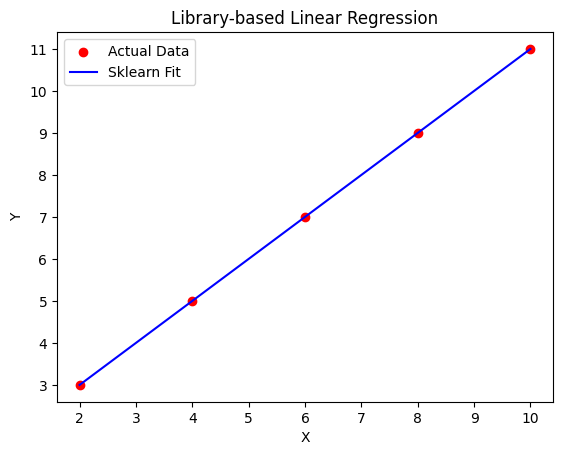

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Dataset
X = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
y = np.array([3, 5, 7, 9, 11])

# 2. Model Training
# Scikit-Learn uses the Ordinary Least Squares (OLS) method by default
model = LinearRegression()
model.fit(X, y)

# 3. Outcomes (Coefficients)
a0 = model.intercept_
a1 = model.coef_[0]
y_pred = model.predict(X)

# 4. Evaluation Metrics using sklearn.metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

# Manual calculation for SSE and MAPE (often used in assignments)
sse = np.sum((y - y_pred)**2)
mape = np.mean(np.abs((y - y_pred) / y)) * 100

# 5. Output Results
print(f"--- Library Results ---")
print(f"Intercept (a0): {a0:.2f}")
print(f"Slope (a1): {a1:.2f}")
print(f"Equation: y = {a0:.2f} + {a1:.2f}x")
print(f"R2 Score: {r2:.2f}")
print(f"MAE: {mae:.2f}")
print(f"SSE: {sse:.2f}")

# 6. Plotting the Fit
plt.scatter(X, y, color='red', label='Actual Data')
plt.plot(X, y_pred, color='blue', label='Sklearn Fit')
plt.title("Library-based Linear Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Dataset from Energy Consumption Study
y_mult = np.array([1.8, 4.7, 3.0, 5.8, 4.8, 7.1, 5.0, 8.0, 7.0, 9.9, 9.0, 11.3, 9.2])
x1 = np.array([20.0, 25.0, 30.5, 35.1, 40.0, 48.2, 55.1, 60.5, 74.9, 80.3, 88.4, 90.1, 95.2])
x2 = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

# Combine independent variables into a single matrix (features)
X = np.column_stack([x1, x2])

# 2. Model Training
# Scikit-Learn handles the intercept (B0) automatically unless fit_intercept=False
model = LinearRegression()
model.fit(X, y_mult)

# 3. Outcomes (Regression Coefficients)
beta0 = model.intercept_
beta1, beta2 = model.coef_
y_pred = model.predict(X)

# 4. Evaluation Metrics
# Note: For Multiple Regression, Adjusted R-Squared is more informative
r2 = r2_score(y_mult, y_pred)
n = len(y_mult)
p = X.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

mae = mean_absolute_error(y_mult, y_pred)
mse = mean_squared_error(y_mult, y_pred)

# 5. Prediction for Specific Case
# Income=2, Ownership=1.5
test_case = np.array([[2.0, 1.5]])
prediction = model.predict(test_case)

# 6. Output Results
print(f"--- Multiple LR Library Results ---")
print(f"Intercept (B0): {beta0:.4f}")
print(f"Income Coeff (B1): {beta1:.4f}")
print(f"Ownership Coeff (B2): {beta2:.4f}")
print(f"R-Squared: {r2:.4f}")
print(f"Adjusted R-Squared: {adj_r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Prediction for Case (Income=2, Ownership=1.5): {prediction[0]:.2f}")

--- Multiple LR Library Results ---
Intercept (B0): 0.1052
Income Coeff (B1): 0.0967
Ownership Coeff (B2): 2.2298
R-Squared: 0.9857
Adjusted R-Squared: 0.9828
MAE: 0.2477
Prediction for Case (Income=2, Ownership=1.5): 3.64


In [6]:
import numpy as np

# Dataset: Hours studied vs Pass (1) or Fail (0)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_regression_scratch(X, y, alpha=0.1, epochs=1000):
    w0, w1 = 0.0, 0.0
    n = len(X)
    
    for _ in range(epochs):
        # Linear part: z = w0 + w1*X
        z = w0 + w1 * X
        # Activation: h = sigmoid(z)
        h = sigmoid(z)
        
        # Gradients for Log-Loss
        dw0 = (1/n) * np.sum(h - y)
        dw1 = (1/n) * np.sum((h - y) * X)
        
        # Update parameters
        w0 -= alpha * dw0
        w1 -= alpha * dw1
        
    return w0, w1

w0, w1 = logistic_regression_scratch(X, y)
print(f"Scratch Coefficients: w0={w0:.4f}, w1={w1:.4f}")

Scratch Coefficients: w0=-5.6641, w1=1.0799


In [7]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Prepare data for Sklearn (needs 2D X)
X_lib = X.reshape(-1, 1)

# Initialize and fit
model = LogisticRegression()
model.fit(X_lib, y)

# Get the coefficients
b0 = model.intercept_[0]
b1 = model.coef_[0][0]

# Calculate Odds and Probabilities for 5.5 hours of study
test_hours = 5.5
log_odds = b0 + b1 * test_hours
odds = np.exp(log_odds)
prob = model.predict_proba([[test_hours]])[0][1]

print(f"--- Library Results ---")
print(f"Intercept (b0): {b0:.4f}, Slope (b1): {b1:.4f}")
print(f"For {test_hours} hours:")
print(f"Odds of passing: {odds:.2f}")
print(f"Probability of passing: {prob:.2%}")

--- Library Results ---
Intercept (b0): -6.5232, Slope (b1): 1.1861
For 5.5 hours:
Odds of passing: 1.00
Probability of passing: 50.00%
